# Stock Market Prediction Using Machine Learning (Optimised Notebook)

_Last updated: 2026-02-26 14:05 UTC_


1. **Finalise Dataset Selection and Cleaning** (multiple datasets, missing values, scaling, sequencing)
2. **Implement Baseline Models** (Linear Regression, Random Forest)
3. **Build and Train LSTM and GRU Models** (RMSE, MAE, R²)
4. **Time-Aware Validation** (walk-forward and rolling-window)
5. **Initial Results Interpretation** (baseline vs LSTM vs GRU + overfitting signals)
6. **Reproducible Documentation Log** (config + metrics saved to disk)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This part imports all libraries needed for:

**Data handling**: pandas, numpy

**Visualisation**: matplotlib.pyplot

**Math + utilities**: math, os, time, json, warnings

**ML models + metrics**: sklearn (Linear Regression, Random Forest, scalers, error metrics)

**Deep learning**: tensorflow/keras (LSTM, GRU, Dense, Dropout, EarlyStopping)

**Reproducibility**: random seeds


In [ ]:


# Setup: imports + versions

import os, json, time, math, warnings
from dataclasses import asdict, dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")

# TensorFlow/Keras
try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except Exception as e:
    raise ImportError(
        "TensorFlow is required for the LSTM and GRU sections. "
        "Install with: pip install tensorflow"
    ) from e

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("sklearn:", __import__("sklearn").__version__)
print("tensorflow:", tf.__version__)


numpy: 2.0.2
pandas: 2.2.2
sklearn: 1.6.1
tensorflow: 2.19.0


## 1) Dataset selection and cleaning

Supporting multiple datasets (e.g., NASDAQ, AAPL, S&P 500).

**Expected CSV columns** (minimum):
- Date column (e.g., `Date`)
- Price column (e.g., `Close`)



**`DatasetConfig` data class** is a clean way to store metadata for each dataset:

*   **name**: for printing + labelling outputs
*   **csv_path**: where the CSV file is
*   **date_col / price_col**: which columns to use (so your code can work across different CSV formats)


In [ ]:


# Configuration

@dataclass
class DatasetConfig:
    name: str
    csv_path: str
    date_col: str = "Date"
    price_col: str = "Close"

DATASETS: List[DatasetConfig] = [
    DatasetConfig(name="NASDAQ", csv_path="/content/NASDAQ.csv", date_col="Date", price_col="Close"),
    DatasetConfig(name="AAPL",   csv_path="/content/Apple.csv",   date_col="Date", price_col="Close"),
    DatasetConfig(name="S&P 500",  csv_path="/content/S&P500.csv",  date_col="Date", price_col="Close"),
]

# Global modelling config
LOOKBACK = 20                 # timesteps per sample
TEST_SIZE = 0.20              # final hold-out test fraction
VAL_SIZE = 0.10               # validation fraction from training portion (for LSTM early stopping)
SCALER_TYPE = "minmax"        # scale values into range [0, 1].

# Walk-forward / rolling validation
N_FOLDS = 5                   # number of sequential folds
MIN_TRAIN_SIZE = 50           # minimum rows before first fold trains
ROLLING_TRAIN_WINDOW = None   # None = expanding window (train uses all past data); set integer (e.g., 1000) for fixed rolling window
#Training parameters
MAX_EPOCHS = 50
BATCH_SIZE = 32
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configured datasets:")
for ds in DATASETS:
    print(f" - {ds.name}: {ds.csv_path}")


Configured datasets:
 - NASDAQ: /content/NASDAQ.csv
 - AAPL: /content/Apple.csv
 - S&P 500: /content/S&P500.csv


`def load_and_clean_dataset`: Loads a dataset, keeps only Date and Close, sorts chronologically, removes duplicates, and handles missing values.


In [ ]:


# Load + clean helper functionality

def load_and_clean_dataset(cfg: DatasetConfig) -> pd.DataFrame:

    if not os.path.exists(cfg.csv_path):
        raise FileNotFoundError(f"Missing file for {cfg.name}: {cfg.csv_path}")

    # Load CSV and checks that your dataset really contains the chosen date and price columns
    df = pd.read_csv(cfg.csv_path)

    if cfg.date_col not in df.columns or cfg.price_col not in df.columns:
        raise ValueError(
            f"{cfg.name} missing required columns. "
            f"Found columns: {list(df.columns)}; expected {cfg.date_col} and {cfg.price_col}"
        )

    # Extract only (Date, Close)
    data = df[[cfg.date_col, cfg.price_col]].copy()
    # Convert Date to datetime
    data[cfg.date_col] = pd.to_datetime(data[cfg.date_col], errors="coerce")
    data = data.dropna(subset=[cfg.date_col])

    # Coerce price to numeric and revents issues if prices contain commas, symbols, or strings
    data[cfg.price_col] = pd.to_numeric(data[cfg.price_col], errors="coerce")
    data = data.dropna(subset=[cfg.price_col])

    # Sort chronologically and remove duplicate dates, critical for time-series integrity
    data = data.sort_values(cfg.date_col).drop_duplicates(subset=[cfg.date_col], keep="last")

    # Missing values handling (if any remain), prevents gaps from breaking sequence building
    data[cfg.price_col] = data[cfg.price_col].ffill().bfill()

    data = data.reset_index(drop=True)
    return data


def get_scaler(kind: str):
    if kind.lower() == "minmax":
        return MinMaxScaler(feature_range=(0, 1))
    if kind.lower() == "standard":
        return StandardScaler()
    raise ValueError("SCALER_TYPE must be 'minmax' or 'standard'")


def train_val_test_split_time_series(values: np.ndarray, test_size: float):
    '''
    Chronological split.
    Returns trainval_values, test_values
    '''
    n = len(values)
    n_test = max(1, int(n * test_size))
    trainval = values[:-n_test]
    test = values[-n_test:]
    return trainval, test


def make_sequences(series_1d: np.ndarray, lookback: int):
    '''
    Convert a 1D series into supervised sequences.
    X: (samples, lookback, 1), y: (samples,)
    '''
    X, y = [], []
    for i in range(lookback, len(series_1d)):
        X.append(series_1d[i - lookback:i])
        y.append(series_1d[i])
    X = np.array(X).reshape(-1, lookback, 1)
    y = np.array(y).reshape(-1)
    return X, y


def flatten_sequences(X: np.ndarray) -> np.ndarray:
    '''
    For baseline models that need 2D features.
    X: (samples, lookback, 1) -> (samples, lookback)
    '''
    return X.reshape(X.shape[0], X.shape[1])



```
# datasets = {}
for cfg in DATASETS:
    datasets[cfg.name] = load_and_clean_dataset(cfg)
```
Loads every dataset listed in DATASETS into a dictionary like:

`datasets["NASDAQ"] = dataframe`

For easy iteration across datasets.




In [ ]:


# Load datasets (all)

datasets: Dict[str, pd.DataFrame] = {}
for cfg in DATASETS:
    try:
        datasets[cfg.name] = load_and_clean_dataset(cfg)
        print(f"[OK] Loaded {cfg.name}: {len(datasets[cfg.name])} rows")
    except FileNotFoundError as e:
        print(f"[SKIP] {e}")
    except Exception as e:
        print(f"[ERROR] {cfg.name}: {e}")

if not datasets:
    raise RuntimeError("No datasets loaded. Update DATASETS paths to point to your CSV files.")


[OK] Loaded NASDAQ: 2577 rows
[OK] Loaded AAPL: 1255 rows
[OK] Loaded S&P 500: 730 rows


In [ ]:
for name, df in datasets.items():
    print(f"Dataset: {name} (Rows: {len(df)})")
    display(df.head())
    print("\n")

Dataset: NASDAQ (Rows: 2577)


,Date,Close
0,2014-01-02,4143.069824
1,2014-01-03,4131.910156
2,2014-01-06,4113.680176
3,2014-01-07,4153.180176
4,2014-01-08,4165.609863




Dataset: AAPL (Rows: 1255)


,Date,Close
0,2020-06-04,78.329315
1,2020-06-05,80.560219
2,2020-06-08,81.036537
3,2020-06-09,83.595505
4,2020-06-10,85.746208




Dataset: S&P 500 (Rows: 730)


,Date,Close
0,2017-01-02,2279.550049
1,2017-01-03,2395.959961
2,2017-01-05,2388.330078
3,2017-01-06,2430.060059
4,2017-01-08,2476.350098


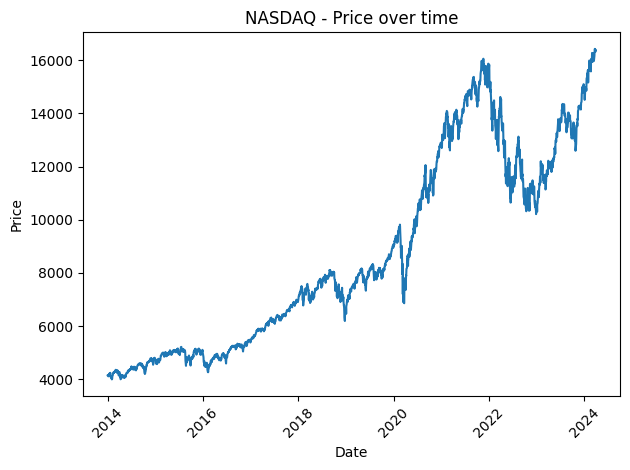

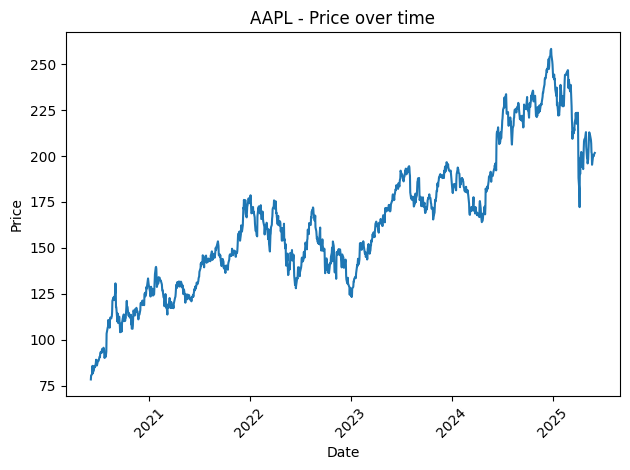

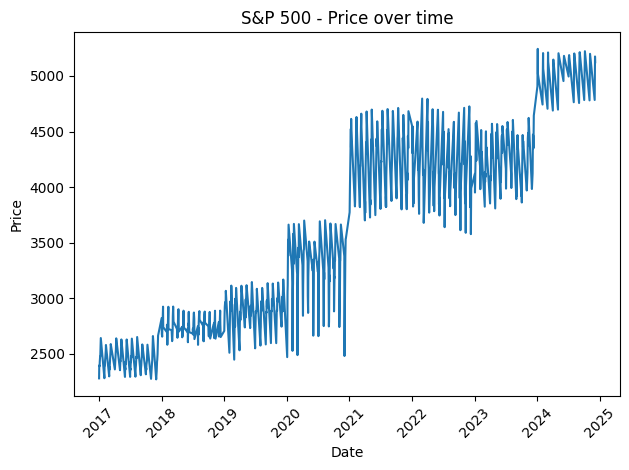

In [ ]:

# Quick visual check (Close over time)
for name, df in datasets.items():
    plt.figure()
    plt.plot(df.iloc[:, 0], df.iloc[:, 1])
    plt.title(f"{name} - Price over time")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 2) Baseline models (Linear Regression + Random Forest)

Baselines use the **same lookback window** but flatten the sequence into a feature vector, so comparisons are fair.

**RMSE**: penalises large errors (sensitive to spikes)

**MAE**: average absolute error (more robust)

**R²**: how much variance the model explains (can be misleading in non-stationary series but still useful)

In [ ]:


# Metrics + evaluation helper

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}


def evaluate_model(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    m = compute_metrics(y_true, y_pred)
    return {"Model": name, **m}


**Linear Regression**

Simple baseline: assumes a linear mapping from past 20 values to the next value.

Why it’s useful:

*   fast

*   interpretable

*   sets a minimum expected performance

**Random Forest**

Why it’s useful:


*   can model non-linear patterns

*   often strong on tabular features


But limitation:

*   it’s not “sequence-aware” like LSTM; it only sees flattened inputs






In [ ]:


# Build baseline models (factory funcs)

def build_linear_regression() -> LinearRegression:
    return LinearRegression()

def build_random_forest() -> RandomForestRegressor:
    return RandomForestRegressor(
        n_estimators=400,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        max_depth=None,
        min_samples_leaf=2
    )


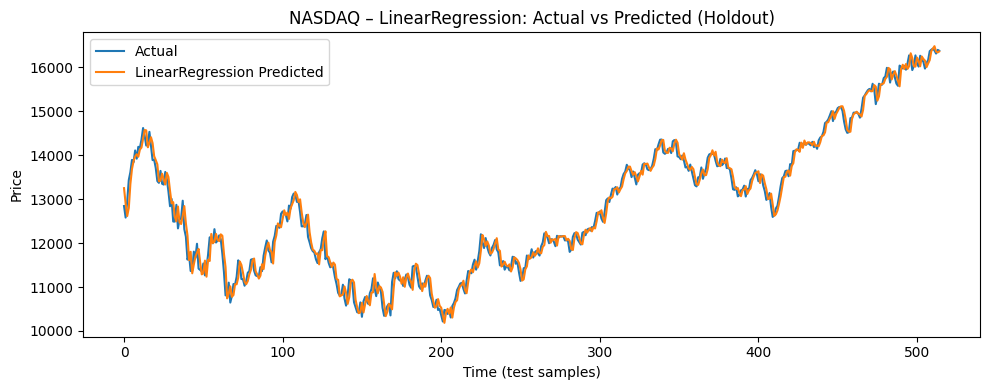

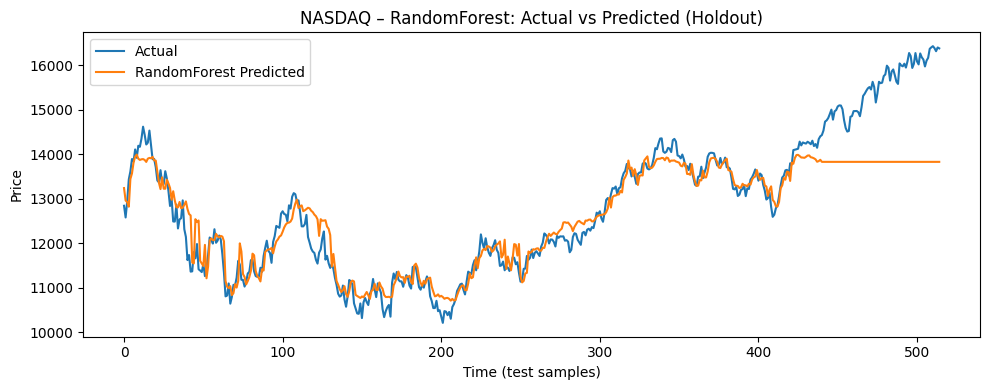

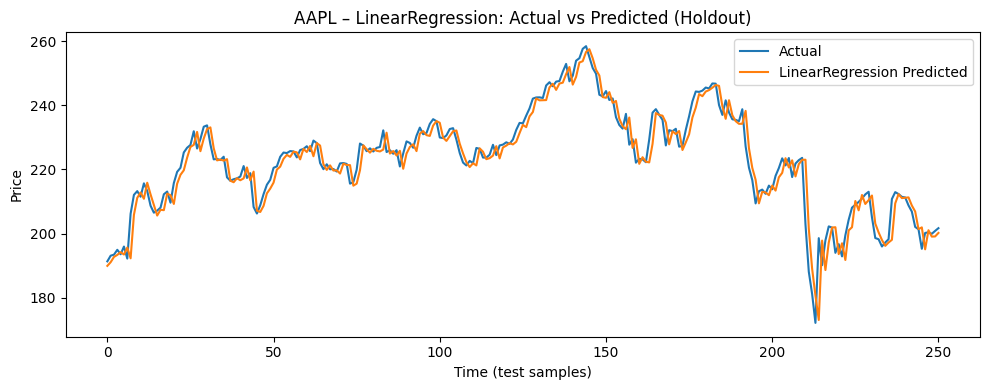

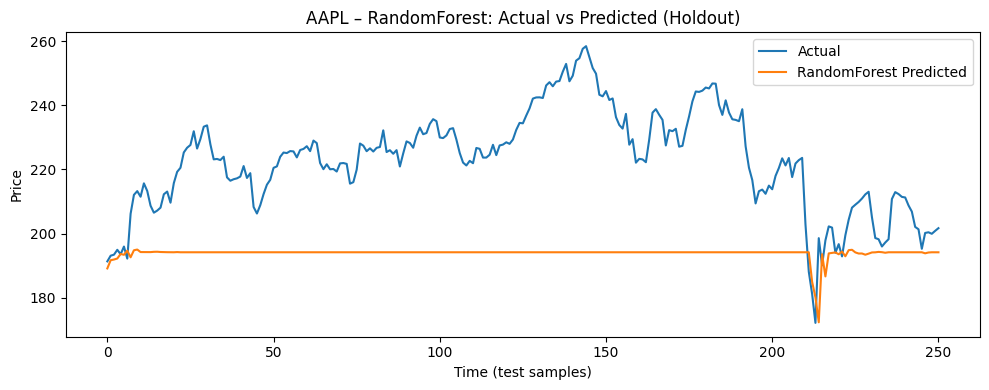

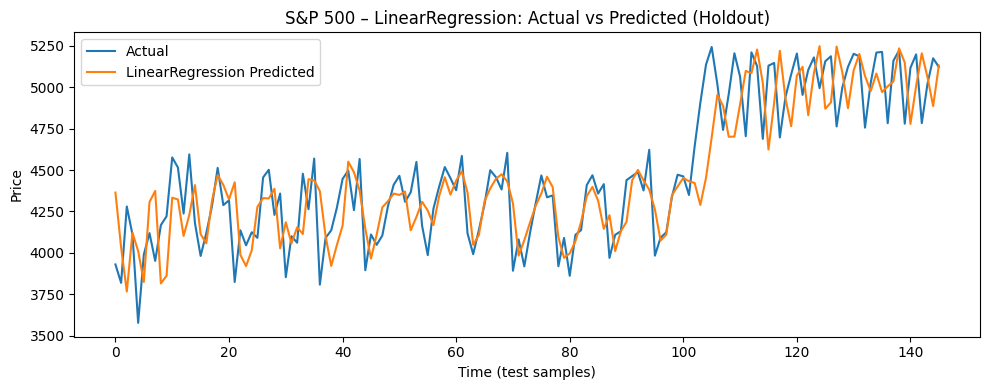

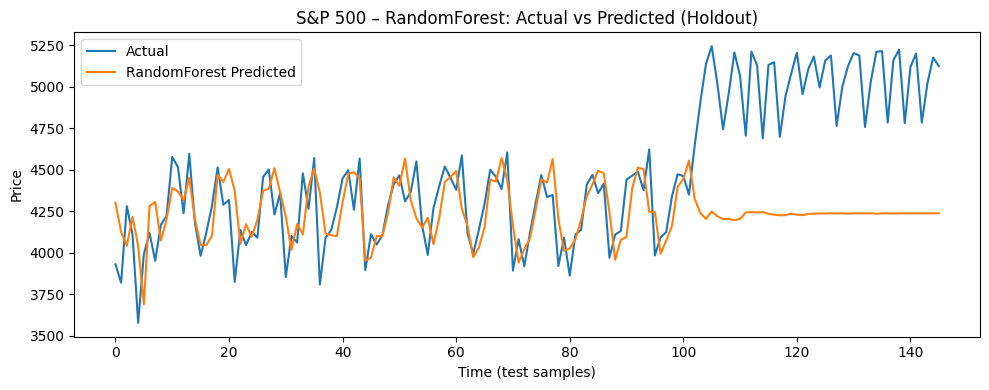

,Model,RMSE,MAE,R2,Dataset,Validation
0,LinearRegression,0.015742,0.012257,0.985422,NASDAQ,Holdout
1,RandomForest,0.061911,0.037425,0.774517,NASDAQ,Holdout
2,LinearRegression,0.036760,0.025858,0.920010,AAPL,Holdout
3,RandomForest,0.275231,0.246477,-3.484184,AAPL,Holdout
4,LinearRegression,0.094266,0.073132,0.678060,S&P 500,Holdout
5,RandomForest,0.187907,0.134585,-0.279229,S&P 500,Holdout


In [ ]:


# Hold-out evaluation (single train/val/test)

def run_holdout_baselines(df: pd.DataFrame, cfg: DatasetConfig, plot: bool = True) -> pd.DataFrame:
    price_col = cfg.price_col

    values = df[price_col].values.reshape(-1, 1)
    # test is the last 20% of time.
    trainval, test = train_val_test_split_time_series(values, TEST_SIZE)

    scaler = get_scaler(SCALER_TYPE)
    scaler.fit(trainval)          # Scale using trainval only (no leakage)
    trainval_s = scaler.transform(trainval).ravel()
    test_s = scaler.transform(test).ravel()

    # Make sequences on scaled data
    X_trainval, y_trainval = make_sequences(trainval_s, LOOKBACK)
    X_test, y_test = make_sequences(np.concatenate([trainval_s[-LOOKBACK:], test_s]), LOOKBACK)

    # Split trainval into train/val chronologically (no shuffle)
    n = len(X_trainval)
    n_val = max(1, int(n * VAL_SIZE))
    X_train, y_train = X_trainval[:-n_val], y_trainval[:-n_val]

    # Flatten sequences for baselines as they require 2D data: (samples, lookback)
    X_train_f = flatten_sequences(X_train)
    X_test_f = flatten_sequences(X_test)

    results = []

    # Helper for plotting in original scale
    def plot_actual_vs_pred(y_test_scaled, y_pred_scaled, model_name: str):
        y_true = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()
        y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 4))
        plt.plot(y_true, label="Actual")
        plt.plot(y_pred, label=f"{model_name} Predicted")
        plt.title(f"{cfg.name} – {model_name}: Actual vs Predicted (Holdout)")
        plt.xlabel("Time (test samples)")
        plt.ylabel("Price")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Linear Regression
    lr = build_linear_regression()
    lr.fit(X_train_f, y_train)
    pred_lr = lr.predict(X_test_f)
    results.append(evaluate_model("LinearRegression", y_test, pred_lr))
    if plot:
        plot_actual_vs_pred(y_test, pred_lr, "LinearRegression")

    # Random Forest
    rf = build_random_forest()
    rf.fit(X_train_f, y_train)
    pred_rf = rf.predict(X_test_f)
    results.append(evaluate_model("RandomForest", y_test, pred_rf))
    if plot:
        plot_actual_vs_pred(y_test, pred_rf, "RandomForest")

    return pd.DataFrame(results)

# Run baselines for all datasets
baseline_holdout_results = []
for cfg in DATASETS:
    if cfg.name not in datasets:
        continue
    df = datasets[cfg.name]
    baseline_holdout_results.append(
        run_holdout_baselines(df, cfg, plot=True).assign(Dataset=cfg.name, Validation="Holdout")
    )

baseline_holdout_results = pd.concat(baseline_holdout_results, ignore_index=True)
baseline_holdout_results


## 3) LSTM and GRU models

Both models are trained on the same scaled sequences using EarlyStopping to reduce overtraining.

- **LSTM** uses gated memory cells with input, forget, and output gates — well-suited to long-range dependencies.
- **GRU** (Gated Recurrent Unit) is a lighter alternative with only two gates (reset and update). It often trains faster and generalises comparably on smaller datasets.

Training stops when validation performance stops improving.


Diagnostics give (for both LSTM and GRU):


*   best validation loss
*   epochs ran
*   final training loss vs final validation loss


In [ ]:


# LSTM + GRU: build + holdout training

def build_lstm_model(lookback: int) -> tf.keras.Model:
    """Stacked LSTM: 64 → Dropout → 32 → Dense(1)."""
    model = Sequential([
        LSTM(64, input_shape=(lookback, 1), return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


def build_gru_model(lookback: int) -> tf.keras.Model:
    """
    Stacked GRU: 64 → Dropout → 32 → Dense(1).
    Mirrors the LSTM architecture for a fair comparison.
    GRU has fewer parameters (no output gate) so typically trains faster.
    """
    model = Sequential([
        GRU(64, input_shape=(lookback, 1), return_sequences=True),
        Dropout(0.2),
        GRU(32),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


def run_holdout_rnn(df: pd.DataFrame, cfg: DatasetConfig, model_name: str = "LSTM"):
    """
    Generic holdout runner for sequence models.
    model_name: 'LSTM' or 'GRU'
    Returns (results_df, diagnostics_dict)
    """
    price_col = cfg.price_col

    values = df[price_col].values.reshape(-1, 1)
    trainval, test = train_val_test_split_time_series(values, TEST_SIZE)

    scaler = get_scaler(SCALER_TYPE)
    scaler.fit(trainval)
    trainval_s = scaler.transform(trainval).ravel()
    test_s = scaler.transform(test).ravel()

    X_trainval, y_trainval = make_sequences(trainval_s, LOOKBACK)
    X_test, y_test = make_sequences(np.concatenate([trainval_s[-LOOKBACK:], test_s]), LOOKBACK)

    n = len(X_trainval)
    n_val = max(1, int(n * VAL_SIZE))
    X_train, y_train = X_trainval[:-n_val], y_trainval[:-n_val]
    X_val, y_val     = X_trainval[-n_val:], y_trainval[-n_val:]

    if model_name == "LSTM":
        model = build_lstm_model(LOOKBACK)
    elif model_name == "GRU":
        model = build_gru_model(LOOKBACK)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es],
        verbose=0
    )

    pred = model.predict(X_test, verbose=0).ravel()
    results = pd.DataFrame([evaluate_model(model_name, y_test, pred)])

    diag = {
        "best_val_loss":    float(np.min(history.history["val_loss"])),
        "epochs_ran":       int(len(history.history["loss"])),
        "final_train_loss": float(history.history["loss"][-1]),
        "final_val_loss":   float(history.history["val_loss"][-1]),
    }
    return results, diag


# Convenience wrappers (preserve backward-compatibility)
def run_holdout_lstm(df, cfg):
    return run_holdout_rnn(df, cfg, model_name="LSTM")

def run_holdout_gru(df, cfg):
    return run_holdout_rnn(df, cfg, model_name="GRU")


# Run LSTM holdout
lstm_holdout_results = []
lstm_diags = []
for cfg in DATASETS:
    if cfg.name not in datasets:
        continue
    res, diag = run_holdout_lstm(datasets[cfg.name], cfg)
    lstm_holdout_results.append(res.assign(Dataset=cfg.name, Validation="Holdout"))
    lstm_diags.append({"Dataset": cfg.name, **diag})

lstm_holdout_results = pd.concat(lstm_holdout_results, ignore_index=True)
lstm_diag_df = pd.DataFrame(lstm_diags)

print("LSTM holdout results:")
display(lstm_holdout_results)
print("\nLSTM diagnostics:")
display(lstm_diag_df)


# Run GRU holdout
gru_holdout_results = []
gru_diags = []
for cfg in DATASETS:
    if cfg.name not in datasets:
        continue
    res, diag = run_holdout_gru(datasets[cfg.name], cfg)
    gru_holdout_results.append(res.assign(Dataset=cfg.name, Validation="Holdout"))
    gru_diags.append({"Dataset": cfg.name, **diag})

gru_holdout_results = pd.concat(gru_holdout_results, ignore_index=True)
gru_diag_df = pd.DataFrame(gru_diags)

print("GRU holdout results:")
display(gru_holdout_results)
print("\nGRU diagnostics:")
display(gru_diag_df)


LSTM holdout results:


,Model,RMSE,MAE,R2,Dataset,Validation
0,LSTM,0.026448,0.021188,0.958850,NASDAQ,Holdout
1,LSTM,0.067060,0.052724,0.733795,AAPL,Holdout
2,LSTM,0.103256,0.085301,0.613725,S&P 500,Holdout



LSTM diagnostics:


,Dataset,best_val_loss,epochs_ran,final_train_loss,final_val_loss
0,NASDAQ,0.000615,38,0.000702,0.000891
1,AAPL,0.001403,39,0.003961,0.002348
2,S&P 500,0.015362,14,0.012286,0.015900


GRU holdout results:


,Model,RMSE,MAE,R2,Dataset,Validation
0,GRU,0.020375,0.016120,0.975577,NASDAQ,Holdout
1,GRU,0.052642,0.041277,0.835956,AAPL,Holdout
2,GRU,0.099509,0.079948,0.641254,S&P 500,Holdout



GRU diagnostics:


,Dataset,best_val_loss,epochs_ran,final_train_loss,final_val_loss
0,NASDAQ,0.000392,43,0.000544,0.000744
1,AAPL,0.000738,40,0.003239,0.001167
2,S&P 500,0.013216,50,0.008712,0.013260


## 4) Time-aware validation: Walk-forward and Rolling-window

This section prevents data leakage by only training on past data and testing on future slices.

- **Expanding (walk-forward):** training window grows each fold.
- **Rolling window:** training window is a fixed-size moving window (set `ROLLING_TRAIN_WINDOW`).

`time_series_folds`
Create sequential train/test slices. Each fold tests on the next chunk of data after the training slice.

`prepare_fold_data`
Fit scaler on training-only, then create sequences for train and test. Test sequences are built by prefixing the last LOOKBACK points from train.

`run_walkforward_baselines`For each fold: build sequences, flatten, train model, predict next chunk, store fold metrics.

Also supports rolling window:

`tr = slice(max(0, te.start - ROLLING_TRAIN_WINDOW), te.start)`

Meaning that I can limit training to the most recent N samples to simulate non-stationary adaptation.

In [ ]:


# Time-aware validation (walk-forward/rolling)

def time_series_folds(n_rows: int, n_folds: int, min_train_size: int):
    if n_rows <= min_train_size + LOOKBACK + 10:
        raise ValueError("Not enough rows for folds. Reduce MIN_TRAIN_SIZE or LOOKBACK, or use a larger dataset.")

    remaining = n_rows - min_train_size
    test_chunk = max(10, remaining // n_folds)

    folds = []
    train_end = min_train_size
    for k in range(n_folds):
        test_start = train_end
        test_end = min(n_rows, test_start + test_chunk)
        if test_end - test_start < 10:
            break
        folds.append((slice(0, train_end), slice(test_start, test_end)))
        train_end = test_end
    return folds


def prepare_fold_data(values_2d: np.ndarray, train_slice: slice, test_slice: slice):

    train_vals = values_2d[train_slice]
    test_vals = values_2d[test_slice]

    scaler = get_scaler(SCALER_TYPE)
    scaler.fit(train_vals)

    train_s = scaler.transform(train_vals).ravel()
    test_s = scaler.transform(test_vals).ravel()

    X_train, y_train = make_sequences(train_s, LOOKBACK)
    X_test, y_test = make_sequences(np.concatenate([train_s[-LOOKBACK:], test_s]), LOOKBACK)
    return X_train, y_train, X_test, y_test


def run_walkforward_baselines(values_2d: np.ndarray, model_name: str):
    folds = time_series_folds(len(values_2d), N_FOLDS, MIN_TRAIN_SIZE)
    out = []
    for i, (tr, te) in enumerate(folds, 1):
        # Rolling window option
        if ROLLING_TRAIN_WINDOW is not None:
            tr = slice(max(0, te.start - ROLLING_TRAIN_WINDOW), te.start)

        X_train, y_train, X_test, y_test = prepare_fold_data(values_2d, tr, te)

        X_train_f = flatten_sequences(X_train)
        X_test_f = flatten_sequences(X_test)

        if model_name == "LinearRegression":
            model = build_linear_regression()
        elif model_name == "RandomForest":
            model = build_random_forest()
        else:
            raise ValueError("Unknown baseline model")

        model.fit(X_train_f, y_train)
        pred = model.predict(X_test_f)

        out.append({"Fold": i, **compute_metrics(y_test, pred)})
    return out


def run_walkforward_lstm(values_2d: np.ndarray):
    folds = time_series_folds(len(values_2d), N_FOLDS, MIN_TRAIN_SIZE)
    out = []
    for i, (tr, te) in enumerate(folds, 1):
        if ROLLING_TRAIN_WINDOW is not None:
            tr = slice(max(0, te.start - ROLLING_TRAIN_WINDOW), te.start)

        X_train, y_train, X_test, y_test = prepare_fold_data(values_2d, tr, te)

        # Internal val split on the training sequences (chronological)
        n = len(X_train)
        n_val = max(1, int(n * VAL_SIZE))
        X_tr, y_tr = X_train[:-n_val], y_train[:-n_val]
        X_val, y_val = X_train[-n_val:], y_train[-n_val:]

        model = build_lstm_model(LOOKBACK)
        es = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)

        model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[es],
            verbose=0
        )

        pred = model.predict(X_test, verbose=0).ravel()
        out.append({"Fold": i, **compute_metrics(y_test, pred)})
    return out


# Run walk-forward/rolling validation across datasets
wf_results = []
for cfg in DATASETS:
    if cfg.name not in datasets:
        continue
    df = datasets[cfg.name]
    values = df[cfg.price_col].values.reshape(-1, 1)

    for m in ["LinearRegression", "RandomForest"]:
        folds = run_walkforward_baselines(values, m)
        wf_results += [{"Dataset": cfg.name, "Model": m, "Validation": "WalkForward", **r} for r in folds]

    folds = run_walkforward_lstm(values)
    wf_results += [{"Dataset": cfg.name, "Model": "LSTM", "Validation": "WalkForward", **r} for r in folds]

wf_df = pd.DataFrame(wf_results)
wf_df.head()

def run_walkforward_gru(values_2d: np.ndarray):
    """
    Walk-forward validation for GRU.
    Architecture mirrors the LSTM fold runner for a fair comparison.
    """
    folds = time_series_folds(len(values_2d), N_FOLDS, MIN_TRAIN_SIZE)
    out = []
    for i, (tr, te) in enumerate(folds, 1):
        if ROLLING_TRAIN_WINDOW is not None:
            tr = slice(max(0, te.start - ROLLING_TRAIN_WINDOW), te.start)

        X_train, y_train, X_test, y_test = prepare_fold_data(values_2d, tr, te)

        n = len(X_train)
        n_val = max(1, int(n * VAL_SIZE))
        X_tr, y_tr   = X_train[:-n_val], y_train[:-n_val]
        X_val, y_val = X_train[-n_val:],  y_train[-n_val:]

        model = build_gru_model(LOOKBACK)
        es = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)

        model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[es],
            verbose=0
        )

        pred = model.predict(X_test, verbose=0).ravel()
        out.append({"Fold": i, **compute_metrics(y_test, pred)})
    return out


# Run walk-forward for all datasets: LR, RF, LSTM, GRU
wf_rows = []
for cfg in DATASETS:
    if cfg.name not in datasets:
        continue
    values_2d = datasets[cfg.name][cfg.price_col].values.reshape(-1, 1)
    ds_name = cfg.name

    for model_label in ["LinearRegression", "RandomForest"]:
        rows = run_walkforward_baselines(values_2d, model_label)
        for r in rows:
            wf_rows.append({**r, "Dataset": ds_name, "Model": model_label, "Validation": "WalkForward"})

    for model_label, runner in [("LSTM", run_walkforward_lstm), ("GRU", run_walkforward_gru)]:
        try:
            rows = runner(values_2d)
            for r in rows:
                wf_rows.append({**r, "Dataset": ds_name, "Model": model_label, "Validation": "WalkForward"})
        except Exception as e:
            print(f"[WARN] {ds_name} {model_label} walk-forward skipped: {e}")

wf_df = pd.DataFrame(wf_rows)
print(wf_df.head(10))


   Fold      RMSE       MAE        R2 Dataset             Model   Validation
0     1  0.976010  0.848094 -0.294550  NASDAQ  LinearRegression  WalkForward
1     2  0.042496  0.031744  0.995602  NASDAQ  LinearRegression  WalkForward
2     3  0.034400  0.021012  0.964331  NASDAQ  LinearRegression  WalkForward
3     4  0.032612  0.024932  0.992151  NASDAQ  LinearRegression  WalkForward
4     5  0.015507  0.012080  0.985789  NASDAQ  LinearRegression  WalkForward
5     1  1.405581  1.180491 -1.684865  NASDAQ      RandomForest  WalkForward
6     2  0.876779  0.655120 -0.872161  NASDAQ      RandomForest  WalkForward
7     3  0.207807  0.147691 -0.301651  NASDAQ      RandomForest  WalkForward
8     4  0.650171  0.563086 -2.119420  NASDAQ      RandomForest  WalkForward
9     5  0.027097  0.019572  0.956609  NASDAQ      RandomForest  WalkForward


In [ ]:

# Aggregate fold metrics (mean ± std)
agg = (wf_df
       .groupby(["Dataset","Model","Validation"])
       .agg(RMSE_mean=("RMSE","mean"), RMSE_std=("RMSE","std"),
            MAE_mean=("MAE","mean"),   MAE_std=("MAE","std"),
            R2_mean=("R2","mean"),     R2_std=("R2","std"),
            Folds=("Fold","count"))
       .reset_index()
       .sort_values(["Dataset","RMSE_mean"]))
agg


,Dataset,Model,Validation,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std,Folds
0,AAPL,GRU,WalkForward,0.070485,0.047008,0.055268,0.036687,0.815511,0.076220,5
2,AAPL,LinearRegression,WalkForward,0.082110,0.111895,0.063318,0.088311,0.737031,0.443788,5
1,AAPL,LSTM,WalkForward,0.116260,0.077826,0.094778,0.064621,0.513817,0.192041,5
3,AAPL,RandomForest,WalkForward,0.197669,0.188486,0.162110,0.162394,-0.522573,1.364264,5
6,NASDAQ,LinearRegression,WalkForward,0.220205,0.422622,0.187572,0.369311,0.728665,0.572123,5
4,NASDAQ,GRU,WalkForward,0.245152,0.303236,0.203428,0.258141,0.759980,0.315271,5
5,NASDAQ,LSTM,WalkForward,0.356811,0.353851,0.292903,0.289919,0.502410,0.443736,5
7,NASDAQ,RandomForest,WalkForward,0.633487,0.548751,0.513192,0.459666,-0.804298,1.210682,5
9,S&P 500,LSTM,WalkForward,0.251214,0.127225,0.200207,0.097932,0.269631,0.252846,5
8,S&P 500,GRU,WalkForward,0.258661,0.155239,0.209977,0.130702,0.264037,0.315277,5


## 5) Initial interpretation (baseline vs LSTM vs GRU + overfitting signals)

We compare:
- **Hold-out**: quick snapshot of each model
- **Walk-forward**: realistic sequential performance across 5 folds

Overfitting warning signs:
- Hold-out looks great but walk-forward degrades sharply
- Training loss much lower than validation loss (see diagnostics)

**LSTM vs GRU**: GRU uses fewer parameters (no output gate) so it often trains faster.
Similar or better generalisation on smaller datasets is expected.


In [ ]:
# Merge hold-out results into one table for quick comparison
all_holdout = pd.concat(
    [baseline_holdout_results, lstm_holdout_results, gru_holdout_results],
    ignore_index=True
)
all_holdout = all_holdout[["Dataset","Model","RMSE","MAE","R2","Validation"]].sort_values(["Dataset","RMSE"])
all_holdout


,Dataset,Model,RMSE,MAE,R2,Validation
2,AAPL,LinearRegression,0.036760,0.025858,0.920010,Holdout
10,AAPL,GRU,0.052642,0.041277,0.835956,Holdout
7,AAPL,LSTM,0.067060,0.052724,0.733795,Holdout
3,AAPL,RandomForest,0.275231,0.246477,-3.484184,Holdout
0,NASDAQ,LinearRegression,0.015742,0.012257,0.985422,Holdout
9,NASDAQ,GRU,0.020375,0.016120,0.975577,Holdout
6,NASDAQ,LSTM,0.026448,0.021188,0.958850,Holdout
1,NASDAQ,RandomForest,0.061911,0.037425,0.774517,Holdout
4,S&P 500,LinearRegression,0.094266,0.073132,0.678060,Holdout
11,S&P 500,GRU,0.099509,0.079948,0.641254,Holdout


For each dataset it prints:

*   Holdout ranking (best RMSE)

*   Walk-forward mean ± std

*   LSTM diagnostic summary

*   Overfitting warning if val loss noticeably higher than train loss


In [ ]:
def interpret_results(
    holdout: pd.DataFrame,
    walkforward_agg: pd.DataFrame,
    lstm_diag: pd.DataFrame,
    gru_diag: pd.DataFrame
) -> None:
    for ds in sorted(holdout["Dataset"].unique()):
        print("="*70)
        print(f"DATASET: {ds}")
        h = holdout[holdout["Dataset"]==ds].sort_values("RMSE")
        print("\nHold-out ranking (lower RMSE is better):")
        print(h[["Model","RMSE","MAE","R2"]].to_string(index=False))

        w = walkforward_agg[walkforward_agg["Dataset"]==ds].sort_values("RMSE_mean")
        print("\nWalk-forward (mean ± std):")
        for _, row in w.iterrows():
            print(f" - {row['Model']}: RMSE {row['RMSE_mean']:.4f} ± {row['RMSE_std']:.4f}, "
                  f"MAE {row['MAE_mean']:.4f} ± {row['MAE_std']:.4f}, "
                  f"R² {row['R2_mean']:.4f} ± {row['R2_std']:.4f} (folds={row['Folds']})")

        for label, diag_df in [("LSTM", lstm_diag), ("GRU", gru_diag)]:
            d = diag_df[diag_df["Dataset"]==ds]
            if len(d):
                best        = float(d["best_val_loss"].iloc[0])
                final_train = float(d["final_train_loss"].iloc[0])
                final_val   = float(d["final_val_loss"].iloc[0])
                gap         = final_val - final_train
                print(f"\n{label} training diagnostics (hold-out run):")
                print(f" - epochs_ran:       {int(d['epochs_ran'].iloc[0])}")
                print(f" - final_train_loss: {final_train:.6f}")
                print(f" - final_val_loss:   {final_val:.6f}")
                print(f" - best_val_loss:    {best:.6f}")
                if gap > 0.002:
                    print(f" - note: validation loss noticeably higher than training loss → possible overfitting.")
                else:
                    print(f" - note: train/val loss gap looks reasonable.")

interpret_results(all_holdout, agg, lstm_diag_df, gru_diag_df)


DATASET: AAPL

Hold-out ranking (lower RMSE is better):
           Model     RMSE      MAE        R2
LinearRegression 0.036760 0.025858  0.920010
             GRU 0.052642 0.041277  0.835956
            LSTM 0.067060 0.052724  0.733795
    RandomForest 0.275231 0.246477 -3.484184

Walk-forward (mean ± std):
 - GRU: RMSE 0.0705 ± 0.0470, MAE 0.0553 ± 0.0367, R² 0.8155 ± 0.0762 (folds=5)
 - LinearRegression: RMSE 0.0821 ± 0.1119, MAE 0.0633 ± 0.0883, R² 0.7370 ± 0.4438 (folds=5)
 - LSTM: RMSE 0.1163 ± 0.0778, MAE 0.0948 ± 0.0646, R² 0.5138 ± 0.1920 (folds=5)
 - RandomForest: RMSE 0.1977 ± 0.1885, MAE 0.1621 ± 0.1624, R² -0.5226 ± 1.3643 (folds=5)

LSTM training diagnostics (hold-out run):
 - epochs_ran:       39
 - final_train_loss: 0.003961
 - final_val_loss:   0.002348
 - best_val_loss:    0.001403
 - note: train/val loss gap looks reasonable.

GRU training diagnostics (hold-out run):
 - epochs_ran:       40
 - final_train_loss: 0.003239
 - final_val_loss:   0.001167
 - best_val_loss: 

## 6) Documentation log (reproducible)

This writes out:
- `experiment_config.json`
- `holdout_metrics.csv`
- `walkforward_metrics.csv`
- `walkforward_aggregate.csv`
- `lstm_diagnostics.csv`
- `gru_diagnostics.csv`

These files can be referenced directly in the final report methods/results sections.


In [ ]:


# Save a reproducible log

config_dump = {
    "LOOKBACK": LOOKBACK,
    "TEST_SIZE": TEST_SIZE,
    "VAL_SIZE": VAL_SIZE,
    "SCALER_TYPE": SCALER_TYPE,
    "N_FOLDS": N_FOLDS,
    "MIN_TRAIN_SIZE": MIN_TRAIN_SIZE,
    "ROLLING_TRAIN_WINDOW": ROLLING_TRAIN_WINDOW,
    "MAX_EPOCHS": MAX_EPOCHS,
    "BATCH_SIZE": BATCH_SIZE,
    "RANDOM_SEED": RANDOM_SEED,
    "DATASETS": [asdict(ds) for ds in DATASETS],
    "timestamp_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
}

with open(os.path.join(OUTPUT_DIR, "experiment_config.json"), "w", encoding="utf-8") as f:
    json.dump(config_dump, f, indent=2)

all_holdout.to_csv(os.path.join(OUTPUT_DIR, "holdout_metrics.csv"), index=False)
wf_df.to_csv(os.path.join(OUTPUT_DIR, "walkforward_metrics.csv"), index=False)
agg.to_csv(os.path.join(OUTPUT_DIR, "walkforward_aggregate.csv"), index=False)
lstm_diag_df.to_csv(os.path.join(OUTPUT_DIR, "lstm_diagnostics.csv"), index=False)
gru_diag_df.to_csv(os.path.join(OUTPUT_DIR, "gru_diagnostics.csv"), index=False)

print("Saved outputs to:", os.path.abspath(OUTPUT_DIR))
print("Files:", os.listdir(OUTPUT_DIR))


Saved outputs to: /content/outputs
Files: ['experiment_config.json', 'walkforward_metrics.csv', 'lstm_diagnostics.csv', 'gru_diagnostics.csv', 'holdout_metrics.csv', 'walkforward_aggregate.csv']


## 7) Visual comparison — LSTM vs GRU across all datasets

Loops over every loaded dataset and produces one chart per dataset,
plotting actual prices against both LSTM and GRU predictions on the holdout window.
Metrics (RMSE, MAE, R²) are printed for each model and dataset before its chart.



Dataset: NASDAQ
LSTM → RMSE: 326.7876, MAE: 259.6719, R²: 0.9568
GRU → RMSE: 285.7301, MAE: 224.3832, R²: 0.9670


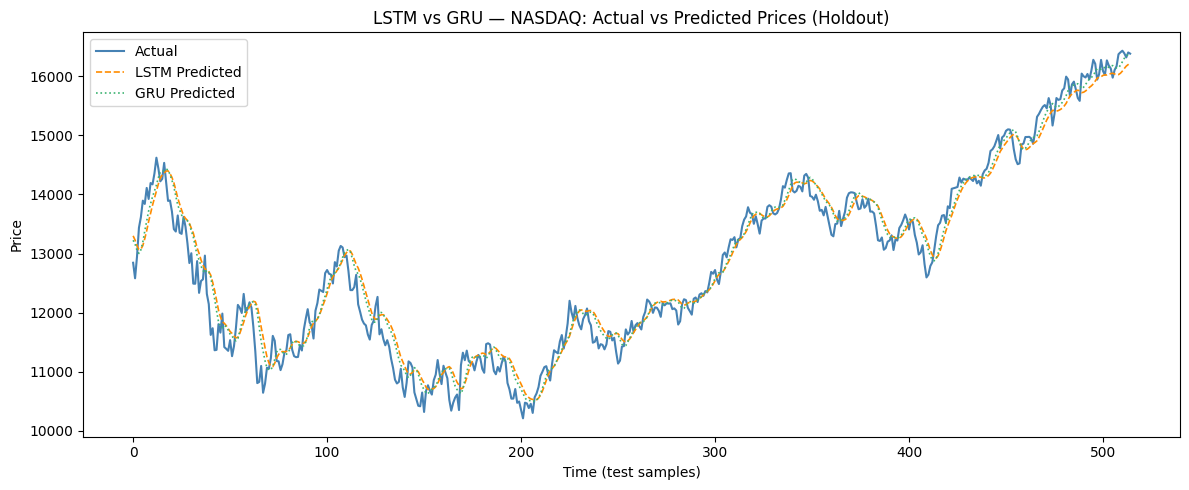


Dataset: AAPL
LSTM → RMSE: 8.0659, MAE: 6.3585, R²: 0.7250
GRU → RMSE: 6.0439, MAE: 4.4292, R²: 0.8456


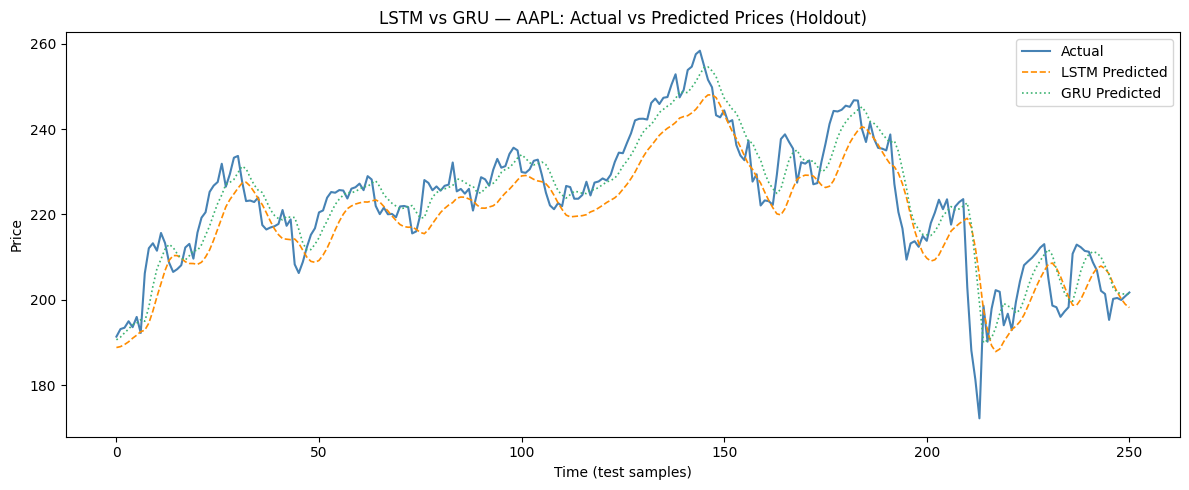


Dataset: S&P 500
LSTM → RMSE: 280.6205, MAE: 233.7290, R²: 0.5529
GRU → RMSE: 239.6532, MAE: 189.4580, R²: 0.6739


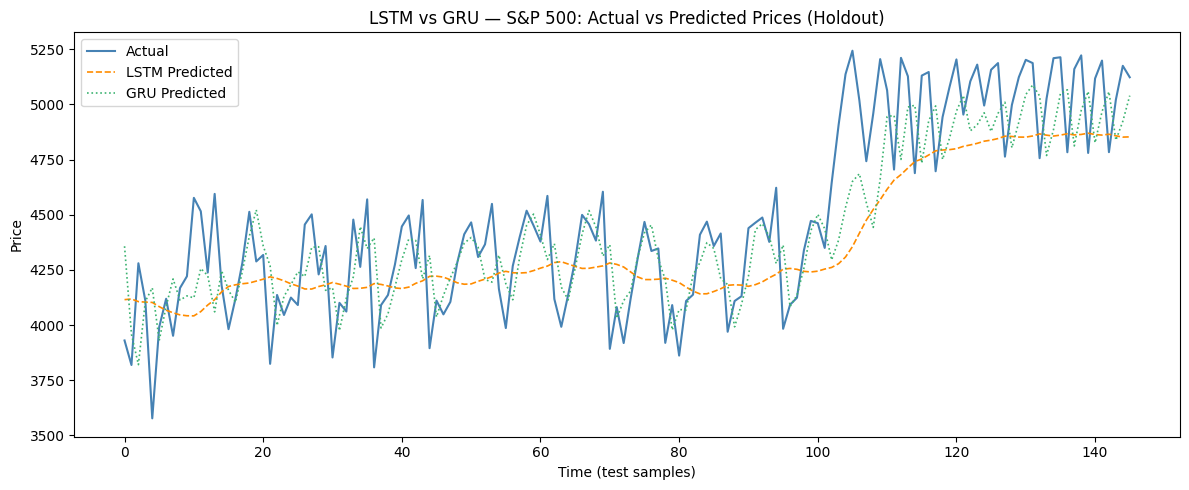

In [ ]:
# Visual comparison: LSTM vs GRU across all datasets

for cfg in DATASETS:
    if cfg.name not in datasets:
        print(f"[SKIP] {cfg.name} not loaded.")
        continue

    print(f"\n{'='*60}")
    print(f"Dataset: {cfg.name}")
    print('='*60)

    df_plot        = datasets[cfg.name]
    price_col_plot = cfg.price_col

    # Prepare data
    values_plot = df_plot[price_col_plot].values.reshape(-1, 1)
    trainval_plot, test_plot = train_val_test_split_time_series(values_plot, TEST_SIZE)

    scaler = get_scaler(SCALER_TYPE)
    scaler.fit(trainval_plot)
    trainval_s_plot = scaler.transform(trainval_plot).ravel()
    test_s_plot     = scaler.transform(test_plot).ravel()

    X_trainval_plot, y_trainval = make_sequences(trainval_s_plot, LOOKBACK)
    X_test_plot, y_test         = make_sequences(
        np.concatenate([trainval_s_plot[-LOOKBACK:], test_s_plot]), LOOKBACK
    )

    n_plot     = len(X_trainval_plot)
    n_val_plot = max(1, int(n_plot * VAL_SIZE))
    X_train_plot, y_train_plot = X_trainval_plot[:-n_val_plot], y_trainval[:-n_val_plot]
    X_val_plot,   y_val_plot   = X_trainval_plot[-n_val_plot:],  y_trainval[-n_val_plot:]

    # Train LSTM
    lstm_model = build_lstm_model(LOOKBACK)
    lstm_model.fit(
        X_train_plot, y_train_plot,
        validation_data=(X_val_plot, y_val_plot),
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
        callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
        verbose=0
    )
    y_pred_lstm_scaled = lstm_model.predict(X_test_plot, verbose=0).ravel()

    # Train GRU
    gru_model = build_gru_model(LOOKBACK)
    gru_model.fit(
        X_train_plot, y_train_plot,
        validation_data=(X_val_plot, y_val_plot),
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
        callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
        verbose=0
    )
    y_pred_gru_scaled = gru_model.predict(X_test_plot, verbose=0).ravel()

    # Inverse-transform to original price scale
    y_true   = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
    y_pred_l = scaler.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).ravel()
    y_pred_g = scaler.inverse_transform(y_pred_gru_scaled.reshape(-1, 1)).ravel()

    # Metrics
    for label, y_pred in [("LSTM", y_pred_l), ("GRU", y_pred_g)]:
        rmse = mean_squared_error(y_true, y_pred) ** 0.5
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        print(f"{label} → RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(y_true,   label="Actual",         color="steelblue",      linewidth=1.5)
    plt.plot(y_pred_l, label="LSTM Predicted", color="darkorange",     linewidth=1.2, linestyle="--")
    plt.plot(y_pred_g, label="GRU Predicted",  color="mediumseagreen", linewidth=1.2, linestyle=":")
    plt.title(f"LSTM vs GRU — {cfg.name}: Actual vs Predicted Prices (Holdout)")
    plt.xlabel("Time (test samples)")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.show()
